In [ ]:
# ============================================================
# 1) Install dependencies
# ============================================================
!pip install -q aeon torch scikit-learn matplotlib numpy pandas

In [ ]:
# ============================================================
# 2) Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from aeon.datasets import load_classification
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

In [ ]:
# ============================================================
# 3) Global config
# ============================================================
CONFIG = {
    "target_length": 150,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "hidden_dim": 64,
    "num_classes": 2,
    "lr": 1e-3,
    "batch_size": 16,
    "epochs": 30,
    "ewc_lambda": 200.0,
    "lwf_alpha": 1.0,
    "lwf_temperature": 2.0,
    "replay_per_class": 100,
    "tsfd_alpha_logits": 1.0,
    "tsfd_alpha_features": 0.5,
    "tsfd_temperature": 2.0,
    "proto_memory_per_class": 20,
    "proto_alpha": 0.5,
}

SEQUENCES = [
    ["GunPoint", "ItalyPowerDemand", "SonyAIBORobotSurface1"],
    ["GunPoint", "SonyAIBORobotSurface1", "SonyAIBORobotSurface2"],
]

SEEDS = [0, 1, 2, 3, 4]

device = torch.device(CONFIG["device"])
print("Using device:", device)

Using device: cpu


In [ ]:
# ============================================================
# 4) Utilities
# ============================================================
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def resize_1d_series(x, target_length):
    old_idx = np.linspace(0, 1, len(x))
    new_idx = np.linspace(0, 1, target_length)
    return np.interp(new_idx, old_idx, x).astype(np.float32)

def make_loader(X, y, batch_size=16, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

def accuracy(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            targets.extend(yb.cpu().numpy())
    return accuracy_score(targets, preds)

In [ ]:
# ============================================================
# 5) Task abstraction
# ============================================================
@dataclass
class TimeSeriesTask:
    name: str
    X_train: np.ndarray
    y_train: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray

class AeonTaskLoader:
    def __init__(self, target_length=150, only_first_channel=True):
        self.target_length = target_length
        self.only_first_channel = only_first_channel

    def load_task(self, dataset_name):
        X_train, y_train = load_classification(dataset_name, split="train")
        X_test, y_test = load_classification(dataset_name, split="test")

        if X_train.ndim == 3:
            if self.only_first_channel:
                X_train = X_train[:, 0, :]
                X_test = X_test[:, 0, :]
            else:
                raise ValueError("Multivariate handling not implemented yet.")
        elif X_train.ndim != 2:
            raise ValueError(f"Unexpected shape for {dataset_name}: {X_train.shape}")

        X_train = np.array([resize_1d_series(x, self.target_length) for x in X_train], dtype=np.float32)
        X_test = np.array([resize_1d_series(x, self.target_length) for x in X_test], dtype=np.float32)

        le = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_test = le.transform(y_test)

        n_classes = len(np.unique(y_train))
        if n_classes != 2:
            raise ValueError(f"{dataset_name} is not binary. Found {n_classes} classes.")

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train).astype(np.float32)
        X_test = scaler.transform(X_test).astype(np.float32)

        return TimeSeriesTask(
            name=dataset_name,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test
        )

    def load_sequence(self, dataset_names):
        return [self.load_task(name) for name in dataset_names]

In [ ]:
# ============================================================
# 6) Models
# ============================================================
class FeatureMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def extract_features(self, x):
        return self.relu(self.fc1(x))

    def forward(self, x):
        feats = self.extract_features(x)
        logits = self.fc2(feats)
        return logits

In [ ]:
# ============================================================
# 7) Base continual learning strategy
# ============================================================
class BaseStrategy:
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30):
        self.model = model.to(device)
        self.device = device
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.ce_loss = nn.CrossEntropyLoss()

    def train_epoch(self, loader, extra_loss_fn=None):
        self.model.train()
        for xb, yb in loader:
            xb, yb = xb.to(self.device), yb.to(self.device)

            self.optimizer.zero_grad()
            logits = self.model(xb)
            loss = self.ce_loss(logits, yb)

            if extra_loss_fn is not None:
                extra = extra_loss_fn(xb, yb, logits)
                if isinstance(extra, (int, float)):
                    extra = torch.tensor(extra, dtype=torch.float32, device=self.device)
                loss = loss + extra

            loss.backward()
            self.optimizer.step()

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
        for _ in range(self.epochs):
            self.train_epoch(loader)

    def evaluate_task(self, task):
        loader = make_loader(task.X_test, task.y_test, batch_size=self.batch_size, shuffle=False)
        return accuracy(self.model, loader, self.device)

In [ ]:
# ============================================================
# 8) Baseline strategy
# ============================================================
class BaselineStrategy(BaseStrategy):
    pass

In [ ]:
# ============================================================
# 9) EWC strategy
# ============================================================
class EWCStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, ewc_lambda=200.0):
        super().__init__(model, device, lr, batch_size, epochs)
        self.ewc_lambda = ewc_lambda
        self.fisher = None
        self.old_params = None

    def compute_fisher(self, task):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
        fisher = {n: torch.zeros_like(p) for n, p in self.model.named_parameters()}

        self.model.eval()
        for xb, yb in loader:
            xb, yb = xb.to(self.device), yb.to(self.device)
            self.model.zero_grad()
            logits = self.model(xb)
            loss = self.ce_loss(logits, yb)
            loss.backward()

            for n, p in self.model.named_parameters():
                if p.grad is not None:
                    fisher[n] += p.grad.detach() ** 2

        for n in fisher:
            fisher[n] /= len(loader)

        return fisher

    def save_old_params(self):
        self.old_params = {n: p.detach().clone() for n, p in self.model.named_parameters()}

    def ewc_penalty(self):
        if self.fisher is None or self.old_params is None:
            return torch.tensor(0.0, device=self.device)

        penalty = torch.tensor(0.0, device=self.device)
        for n, p in self.model.named_parameters():
            penalty += (self.fisher[n] * (p - self.old_params[n]) ** 2).sum()
        return 0.5 * self.ewc_lambda * penalty

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.ewc_penalty()

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.fisher = self.compute_fisher(task)
        self.save_old_params()

In [ ]:
# ============================================================
# 10) LwF strategy
# ============================================================
class LwFStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, alpha=1.0, temperature=2.0):
        super().__init__(model, device, lr, batch_size, epochs)
        self.alpha = alpha
        self.temperature = temperature
        self.teacher = None
        self.kl = nn.KLDivLoss(reduction="batchmean")

    def distillation_loss(self, xb, logits):
        if self.teacher is None:
            return torch.tensor(0.0, device=self.device)

        with torch.no_grad():
            teacher_logits = self.teacher(xb)

        student_log_probs = torch.log_softmax(logits / self.temperature, dim=1)
        teacher_probs = torch.softmax(teacher_logits / self.temperature, dim=1)
        return self.alpha * self.kl(student_log_probs, teacher_probs) * (self.temperature ** 2)

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.distillation_loss(xb, logits)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.teacher = deepcopy(self.model).to(self.device)
        self.teacher.eval()

In [ ]:
# ============================================================
# 11) Replay strategy
# ============================================================
class ReplayStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, replay_per_class=100):
        super().__init__(model, device, lr, batch_size, epochs)
        self.replay_per_class = replay_per_class
        self.replay_stats = None

    def fit_class_gaussians(self, X, y):
        stats = {}
        for c in np.unique(y):
            Xc = X[y == c]
            mean = Xc.mean(axis=0)
            var = Xc.var(axis=0) + 1e-4
            stats[c] = (mean, var)
        return stats

    def sample_replay(self):
        Xs, ys = [], []
        for c, (mean, var) in self.replay_stats.items():
            samples = np.random.randn(self.replay_per_class, len(mean)) * np.sqrt(var) + mean
            Xs.append(samples.astype(np.float32))
            ys.append(np.full(self.replay_per_class, c))
        return np.vstack(Xs), np.concatenate(ys)

    def fit_task(self, task, task_id=None):
        if task_id == 0:
            loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)
            self.replay_stats = self.fit_class_gaussians(task.X_train, task.y_train)
        else:
            X_replay, y_replay = self.sample_replay()
            X_mix = np.vstack([task.X_train, X_replay]).astype(np.float32)
            y_mix = np.concatenate([task.y_train, y_replay])

            loader = make_loader(X_mix, y_mix, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)

            self.replay_stats = self.fit_class_gaussians(X_mix, y_mix)

In [ ]:
# ============================================================
# 12) TS-FeatureDistill strategy
# ============================================================
class TSFeatureDistillStrategy(BaseStrategy):
    def __init__(
        self,
        model,
        device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        alpha_logits=1.0,
        alpha_features=1.0,
        temperature=2.0,
    ):
        super().__init__(model, device, lr, batch_size, epochs)
        self.alpha_logits = alpha_logits
        self.alpha_features = alpha_features
        self.temperature = temperature
        self.teacher = None
        self.kl = nn.KLDivLoss(reduction="batchmean")
        self.mse = nn.MSELoss()

    def distill_loss(self, xb, logits):
        if self.teacher is None:
            return torch.tensor(0.0, device=self.device)

        with torch.no_grad():
            teacher_logits = self.teacher(xb)
            teacher_feats = self.teacher.extract_features(xb)

        student_log_probs = torch.log_softmax(logits / self.temperature, dim=1)
        teacher_probs = torch.softmax(teacher_logits / self.temperature, dim=1)
        logit_loss = self.kl(student_log_probs, teacher_probs) * (self.temperature ** 2)

        student_feats = self.model.extract_features(xb)
        feat_loss = self.mse(student_feats, teacher_feats)

        return self.alpha_logits * logit_loss + self.alpha_features * feat_loss

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.distill_loss(xb, logits)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.teacher = deepcopy(self.model).to(self.device)
        self.teacher.eval()

In [ ]:
# ============================================================
# 13) TS-ProtoReplay strategy
# ============================================================
class TSProtoReplayStrategy(BaseStrategy):
    def __init__(
        self,
        model,
        device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        memory_per_class=20,
        alpha_proto=1.0,
    ):
        super().__init__(model, device, lr, batch_size, epochs)
        self.memory_per_class = memory_per_class
        self.alpha_proto = alpha_proto
        self.memory_X = []
        self.memory_y = []
        self.prototypes = {}
        self.mse = nn.MSELoss()

    def update_memory(self, X, y):
        mem_X, mem_y = [], []
        classes = np.unique(y)

        for c in classes:
            Xc = X[y == c]
            n = min(self.memory_per_class, len(Xc))
            idx = np.random.choice(len(Xc), size=n, replace=False)
            mem_X.append(Xc[idx])
            mem_y.append(np.full(n, c))

        mem_X = np.vstack(mem_X).astype(np.float32)
        mem_y = np.concatenate(mem_y)

        self.memory_X.append(mem_X)
        self.memory_y.append(mem_y)

    def get_memory(self):
        if len(self.memory_X) == 0:
            return None, None
        X_mem = np.vstack(self.memory_X).astype(np.float32)
        y_mem = np.concatenate(self.memory_y)
        return X_mem, y_mem

    def update_prototypes(self):
        X_mem, y_mem = self.get_memory()
        if X_mem is None:
            return

        self.model.eval()
        X_t = torch.tensor(X_mem, dtype=torch.float32).to(self.device)
        y_t = torch.tensor(y_mem, dtype=torch.long).to(self.device)

        with torch.no_grad():
            feats = self.model.extract_features(X_t)

        self.prototypes = {}
        for c in torch.unique(y_t):
            mask = y_t == c
            proto = feats[mask].mean(dim=0)
            self.prototypes[int(c.item())] = proto.detach().clone()

    def prototype_loss(self, xb, yb):
        if len(self.prototypes) == 0:
            return torch.tensor(0.0, device=self.device)

        feats = self.model.extract_features(xb)
        loss = torch.tensor(0.0, device=self.device)
        count = 0

        for c, proto in self.prototypes.items():
            mask = (yb == c)
            if mask.sum() > 0:
                loss += self.mse(feats[mask].mean(dim=0), proto.to(self.device))
                count += 1

        if count == 0:
            return torch.tensor(0.0, device=self.device)
        return self.alpha_proto * loss / count

    def fit_task(self, task, task_id=None):
        if task_id == 0:
            loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)

            self.update_memory(task.X_train, task.y_train)
            self.update_prototypes()
        else:
            X_mem, y_mem = self.get_memory()

            if X_mem is not None:
                X_mix = np.vstack([task.X_train, X_mem]).astype(np.float32)
                y_mix = np.concatenate([task.y_train, y_mem])
            else:
                X_mix, y_mix = task.X_train, task.y_train

            loader = make_loader(X_mix, y_mix, batch_size=self.batch_size, shuffle=True)

            def extra_loss_fn(xb, yb, logits):
                return self.prototype_loss(xb, yb)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

            self.update_memory(task.X_train, task.y_train)
            self.update_prototypes()

In [ ]:
# ============================================================
# 14) Metrics
# ============================================================
def final_average_accuracy(acc_matrix):
    """
    Mean accuracy on all seen tasks after the final task.
    """
    last_row = acc_matrix[-1]
    valid = last_row[last_row > 0]
    return valid.mean() if len(valid) > 0 else 0.0

def final_forgetting(acc_matrix):
    """
    Average forgetting over all tasks except the last one:
    max previous accuracy on task t - final accuracy on task t
    """
    n_tasks = acc_matrix.shape[1]
    forgetting = []

    for t in range(n_tasks - 1):
        best_before = np.max(acc_matrix[:, t])
        final_acc = acc_matrix[-1, t]
        forgetting.append(best_before - final_acc)

    return np.mean(forgetting) if len(forgetting) > 0 else 0.0

def per_task_final_accuracy(acc_matrix):
    """
    Final accuracy for each task after learning all tasks.
    """
    return acc_matrix[-1, :]

def backward_transfer(acc_matrix):
    """
    Simple BWT:
    average over tasks except last of (final_acc - acc_when_task_was_learned)
    Negative values mean forgetting.
    """
    n_tasks = acc_matrix.shape[0]
    bwt_vals = []

    for t in range(n_tasks - 1):
        final_acc = acc_matrix[-1, t]
        learned_acc = acc_matrix[t, t]
        bwt_vals.append(final_acc - learned_acc)

    return np.mean(bwt_vals) if len(bwt_vals) > 0 else 0.0

In [ ]:
# ============================================================
# 15) Experiment runner
# ============================================================
class ContinualLearningExperiment:
    def __init__(self, tasks, strategy_dict):
        self.tasks = tasks
        self.strategy_dict = strategy_dict
        self.results = {}

    def run(self):
        for name, strategy in self.strategy_dict.items():
            print(f"\nRunning strategy: {name}")
            n_tasks = len(self.tasks)
            acc_matrix = np.zeros((n_tasks, n_tasks))

            for task_id, task in enumerate(self.tasks):
                print(f"  Training on task {task_id+1}: {task.name}")
                strategy.fit_task(task, task_id=task_id)

                for eval_id in range(task_id + 1):
                    acc = strategy.evaluate_task(self.tasks[eval_id])
                    acc_matrix[task_id, eval_id] = acc
                    print(f"    Eval on task {eval_id+1} ({self.tasks[eval_id].name}): {acc:.4f}")

            self.results[name] = acc_matrix

        return self.results

    def summary(self):
        rows = []
        for name, acc_matrix in self.results.items():
            row = {
                "method": name,
                "final_avg_acc": final_average_accuracy(acc_matrix),
                "final_forgetting": final_forgetting(acc_matrix),
                "backward_transfer": backward_transfer(acc_matrix),
            }

            final_task_accs = per_task_final_accuracy(acc_matrix)
            for i, acc in enumerate(final_task_accs):
                row[f"final_task{i+1}_acc"] = acc

            rows.append(row)

        return pd.DataFrame(rows)

In [ ]:
# ============================================================
# 16) Strategy factory
# ============================================================
def make_strategies(input_dim, device):
    return {
        "Baseline": BaselineStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"]
        ),
        "EWC": EWCStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            ewc_lambda=CONFIG["ewc_lambda"]
        ),
        "LwF": LwFStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            alpha=CONFIG["lwf_alpha"],
            temperature=CONFIG["lwf_temperature"]
        ),
        "Replay": ReplayStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            replay_per_class=CONFIG["replay_per_class"]
        ),
        "TS-FeatureDistill": TSFeatureDistillStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            alpha_logits=CONFIG["tsfd_alpha_logits"],
            alpha_features=CONFIG["tsfd_alpha_features"],
            temperature=CONFIG["tsfd_temperature"]
        ),
        "TS-ProtoReplay": TSProtoReplayStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            memory_per_class=CONFIG["proto_memory_per_class"],
            alpha_proto=CONFIG["proto_alpha"]
        ),
    }

In [ ]:
# ============================================================
# 17) Sequence loading helper
# ============================================================
def load_task_sequence(task_names, target_length=150):
    loader = AeonTaskLoader(target_length=target_length)
    tasks = loader.load_sequence(task_names)
    return tasks

In [ ]:
# ============================================================
# 18) Single run: one sequence, one seed
# ============================================================
def run_one_sequence_one_seed(task_names, seed, device, target_length=150, verbose=True):
    set_seed(seed)

    tasks = load_task_sequence(task_names, target_length=target_length)
    input_dim = tasks[0].X_train.shape[1]

    strategies = make_strategies(input_dim, device)

    experiment = ContinualLearningExperiment(tasks, strategies)
    results = experiment.run()
    summary_df = experiment.summary()

    sequence_name = " -> ".join(task_names)
    summary_df["sequence"] = sequence_name
    summary_df["seed"] = seed

    matrices = {}
    for method, acc_matrix in results.items():
        matrices[method] = acc_matrix.copy()

    if verbose:
        print(f"\nFinished sequence: {sequence_name}, seed: {seed}")
        display(summary_df)

    return {
        "sequence": sequence_name,
        "seed": seed,
        "summary": summary_df,
        "matrices": matrices,
        "task_names": task_names,
    }

In [ ]:
# ============================================================
# 19) Full benchmark runner
# ============================================================
def run_benchmark(sequences, seeds, device, target_length=150, verbose=False):
    all_runs = []

    for seq in sequences:
        for seed in seeds:
            print("\n==============================")
            print(f"Running sequence {seq} with seed {seed}")
            print("==============================")

            run_data = run_one_sequence_one_seed(
                task_names=seq,
                seed=seed,
                device=device,
                target_length=target_length,
                verbose=verbose
            )
            all_runs.append(run_data)

    return all_runs

In [ ]:
# ============================================================
# 20) Aggregation helpers
# ============================================================
def aggregate_results(all_runs):
    all_summaries = []
    for run in all_runs:
        all_summaries.append(run["summary"])

    full_df = pd.concat(all_summaries, ignore_index=True)

    metric_cols = [
        "final_avg_acc",
        "final_forgetting",
        "backward_transfer",
    ]

    final_task_cols = [c for c in full_df.columns if c.startswith("final_task") and c.endswith("_acc")]
    metric_cols.extend(final_task_cols)

    agg_dict = {}
    for col in metric_cols:
        agg_dict[f"{col}_mean"] = (col, "mean")
        agg_dict[f"{col}_std"] = (col, "std")

    agg_df = (
        full_df.groupby(["sequence", "method"])
        .agg(**agg_dict)
        .reset_index()
    )

    return full_df, agg_df

In [ ]:
# ============================================================
# 20b) Accuracy matrix aggregation for variable number of tasks
# ============================================================
def aggregate_accuracy_matrices(all_runs):
    rows = []

    for run in all_runs:
        sequence = run["sequence"]
        seed = run["seed"]

        for method, mat in run["matrices"].items():
            n_tasks = mat.shape[0]
            row = {
                "sequence": sequence,
                "seed": seed,
                "method": method,
                "n_tasks": n_tasks,
            }

            for i in range(n_tasks):
                for j in range(n_tasks):
                    row[f"acc_afterT{i+1}_onT{j+1}"] = mat[i, j]

            rows.append(row)

    mat_df = pd.DataFrame(rows)

    acc_cols = [c for c in mat_df.columns if c.startswith("acc_afterT")]
    agg_dict = {}
    for col in acc_cols:
        agg_dict[f"{col}_mean"] = (col, "mean")
        agg_dict[f"{col}_std"] = (col, "std")

    mat_agg = (
        mat_df.groupby(["sequence", "method", "n_tasks"])
        .agg(**agg_dict)
        .reset_index()
    )

    return mat_df, mat_agg

In [ ]:
# ============================================================
# 21) Plotting helpers
# ============================================================
def plot_sequence_results(agg_df, metric="final_avg_acc_mean"):
    sequences = agg_df["sequence"].unique()

    for seq in sequences:
        sub = agg_df[agg_df["sequence"] == seq].copy()

        if metric == "final_avg_acc_mean":
            y = sub["final_avg_acc_mean"].values
            yerr = sub["final_avg_acc_std"].fillna(0).values
            title = f"Final Average Accuracy: {seq}"
            ylabel = "Final Average Accuracy"
        elif metric == "final_forgetting_mean":
            y = sub["final_forgetting_mean"].values
            yerr = sub["final_forgetting_std"].fillna(0).values
            title = f"Final Forgetting: {seq}"
            ylabel = "Final Forgetting"
        elif metric == "backward_transfer_mean":
            y = sub["backward_transfer_mean"].values
            yerr = sub["backward_transfer_std"].fillna(0).values
            title = f"Backward Transfer: {seq}"
            ylabel = "Backward Transfer"
        else:
            raise ValueError("Unsupported metric")

        plt.figure(figsize=(10, 4))
        plt.bar(sub["method"], y, yerr=yerr, capsize=4)
        plt.xticks(rotation=45)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.show()

def plot_mean_accuracy_matrices(mat_agg):
    for _, row in mat_agg.iterrows():
        sequence = row["sequence"]
        method = row["method"]
        n_tasks = int(row["n_tasks"])

        mat = np.zeros((n_tasks, n_tasks))
        for i in range(n_tasks):
            for j in range(n_tasks):
                key = f"acc_afterT{i+1}_onT{j+1}_mean"
                if key in row:
                    mat[i, j] = row[key]

        plt.figure(figsize=(4 + n_tasks, 3 + n_tasks * 0.2))
        plt.imshow(mat, cmap="Blues", vmin=0, vmax=1)
        plt.colorbar(label="Accuracy")
        plt.xticks(range(n_tasks), [f"Task{j+1}" for j in range(n_tasks)])
        plt.yticks(range(n_tasks), [f"After T{i+1}" for i in range(n_tasks)])
        plt.title(f"{method}\n{sequence}")
        plt.tight_layout()
        plt.show()

def plot_final_task_accuracies(agg_df):
    sequences = agg_df["sequence"].unique()

    final_task_cols = [c for c in agg_df.columns if c.startswith("final_task") and c.endswith("_mean")]

    for seq in sequences:
        sub = agg_df[agg_df["sequence"] == seq].copy()
        plt.figure(figsize=(10, 5))

        x = np.arange(len(sub))
        width = 0.8 / max(1, len(final_task_cols))

        for k, col in enumerate(final_task_cols):
            std_col = col.replace("_mean", "_std")
            plt.bar(
                x + k * width,
                sub[col].values,
                width=width,
                yerr=sub[std_col].fillna(0).values if std_col in sub.columns else None,
                capsize=3,
                label=col.replace("_mean", "")
            )

        plt.xticks(x + width * (len(final_task_cols) - 1) / 2, sub["method"], rotation=45)
        plt.ylabel("Accuracy")
        plt.title(f"Final Per-Task Accuracy: {seq}")
        plt.legend()
        plt.show()

In [ ]:
# ============================================================
# 22) Run the full 3-task benchmark
# ============================================================
all_runs = run_benchmark(
    sequences=SEQUENCES,
    seeds=SEEDS,
    device=device,
    target_length=CONFIG["target_length"],
    verbose=False
)


############################################
Running sequence ['GunPoint', 'ItalyPowerDemand', 'SonyAIBORobotSurface1'] with seed 0
############################################


/tmp/ipykernel_45244/2080705927.py:22: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_45244/2080705927.py:23: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_45244/2080705927.py:22: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="tra


Training phase: Task 1 / 3 -> GunPoint

Running strategy: Baseline
  Eval on task 1 (GunPoint): 0.8733

Running strategy: EWC
  Eval on task 1 (GunPoint): 0.8333

Running strategy: LwF
  Eval on task 1 (GunPoint): 0.8667

Running strategy: Replay
  Eval on task 1 (GunPoint): 0.8467

Running strategy: TS-FeatureDistill
  Eval on task 1 (GunPoint): 0.8667

Running strategy: TS-ProtoReplay
  Eval on task 1 (GunPoint): 0.8867

Running ensemble: SoftVotingEnsemble-All
  Included methods: ['Baseline', 'EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Eval on task 1 (GunPoint): 0.8667

Running ensemble: SoftVotingEnsemble-CLOnly
  Included methods: ['EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Eval on task 1 (GunPoint): 0.8667

Running ensemble: RankWeightedSoftVotingEnsemble-All
  Included methods: ['Baseline', 'EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Validation scores: {'Baseline': 0.9, 'EWC': 0.8, 'LwF': 0.8, 'Replay': 0.8, 'TS-Fe

/tmp/ipykernel_45244/2080705927.py:22: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_45244/2080705927.py:23: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_45244/2080705927.py:22: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="tra

  Eval on task 1 (GunPoint): 0.7933

Running strategy: EWC
  Eval on task 1 (GunPoint): 0.7733

Running strategy: LwF
  Eval on task 1 (GunPoint): 0.7400

Running strategy: Replay
  Eval on task 1 (GunPoint): 0.7933

Running strategy: TS-FeatureDistill
  Eval on task 1 (GunPoint): 0.7333

Running strategy: TS-ProtoReplay
  Eval on task 1 (GunPoint): 0.7600

Running ensemble: SoftVotingEnsemble-All
  Included methods: ['Baseline', 'EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Eval on task 1 (GunPoint): 0.7533

Running ensemble: SoftVotingEnsemble-CLOnly
  Included methods: ['EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Eval on task 1 (GunPoint): 0.7533

Running ensemble: RankWeightedSoftVotingEnsemble-All
  Included methods: ['Baseline', 'EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Validation scores: {'Baseline': 0.7, 'EWC': 0.6, 'LwF': 0.5, 'Replay': 0.7, 'TS-FeatureDistill': 0.5, 'TS-ProtoReplay': 0.7}
  Rank-based weights: {'B

...

  Eval on task 1 (GunPoint): 0.9000

Running strategy: EWC
  Eval on task 1 (GunPoint): 0.9067

Running strategy: LwF
  Eval on task 1 (GunPoint): 0.8933

Running strategy: Replay
  Eval on task 1 (GunPoint): 0.9067

Running strategy: TS-FeatureDistill
  Eval on task 1 (GunPoint): 0.9000

Running strategy: TS-ProtoReplay
  Eval on task 1 (GunPoint): 0.8667

Running ensemble: SoftVotingEnsemble-All
  Included methods: ['Baseline', 'EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Eval on task 1 (GunPoint): 0.8933

Running ensemble: SoftVotingEnsemble-CLOnly
  Included methods: ['EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Eval on task 1 (GunPoint): 0.8933

Running ensemble: RankWeightedSoftVotingEnsemble-All
  Included methods: ['Baseline', 'EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Validation scores: {'Baseline': 1.0, 'EWC': 1.0, 'LwF': 1.0, 'Replay': 1.0, 'TS-FeatureDistill': 1.0, 'TS-ProtoReplay': 1.0}
  Rank-based weights: {'B

/tmp/ipykernel_45244/2080705927.py:22: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_45244/2080705927.py:23: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_45244/2080705927.py:22: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="tra

  Eval on task 1 (GunPoint): 0.8867

Running strategy: EWC
  Eval on task 1 (GunPoint): 0.9133

Running strategy: LwF
  Eval on task 1 (GunPoint): 0.9000

Running strategy: Replay
  Eval on task 1 (GunPoint): 0.9067

Running strategy: TS-FeatureDistill
  Eval on task 1 (GunPoint): 0.8667

Running strategy: TS-ProtoReplay
  Eval on task 1 (GunPoint): 0.9000

Running ensemble: SoftVotingEnsemble-All
  Included methods: ['Baseline', 'EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Eval on task 1 (GunPoint): 0.9133

Running ensemble: SoftVotingEnsemble-CLOnly
  Included methods: ['EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Eval on task 1 (GunPoint): 0.9133

Running ensemble: RankWeightedSoftVotingEnsemble-All
  Included methods: ['Baseline', 'EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Validation scores: {'Baseline': 1.0, 'EWC': 1.0, 'LwF': 1.0, 'Replay': 1.0, 'TS-FeatureDistill': 1.0, 'TS-ProtoReplay': 1.0}
  Rank-based weights: {'B

/tmp/ipykernel_45244/2080705927.py:22: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_45244/2080705927.py:23: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_45244/2080705927.py:22: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="tra

  Eval on task 1 (GunPoint): 0.8733

Running strategy: EWC
  Eval on task 1 (GunPoint): 0.8667

Running strategy: LwF
  Eval on task 1 (GunPoint): 0.8733

Running strategy: Replay
  Eval on task 1 (GunPoint): 0.8800

Running strategy: TS-FeatureDistill
  Eval on task 1 (GunPoint): 0.8733

Running strategy: TS-ProtoReplay
  Eval on task 1 (GunPoint): 0.8667

Running ensemble: SoftVotingEnsemble-All
  Included methods: ['Baseline', 'EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Eval on task 1 (GunPoint): 0.8733

Running ensemble: SoftVotingEnsemble-CLOnly
  Included methods: ['EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Eval on task 1 (GunPoint): 0.8733

Running ensemble: RankWeightedSoftVotingEnsemble-All
  Included methods: ['Baseline', 'EWC', 'LwF', 'Replay', 'TS-FeatureDistill', 'TS-ProtoReplay']
  Validation scores: {'Baseline': 0.9, 'EWC': 0.9, 'LwF': 0.9, 'Replay': 0.9, 'TS-FeatureDistill': 0.9, 'TS-ProtoReplay': 0.9}
  Rank-based weights: {'B

In [ ]:
# ============================================================
# 23) Aggregate results
# ============================================================
full_df, agg_df = aggregate_results(all_runs)
mat_df, mat_agg = aggregate_accuracy_matrices(all_runs)

print("\n=== Per-run summary ===")
display(full_df)

print("\n=== Mean / Std summary ===")
display(agg_df)

print("\n=== Mean / Std matrix summary ===")
display(mat_agg)


=== Per-run summary ===


,method,final_avg_acc,final_forgetting,backward_transfer,final_task1_acc,final_task2_acc,final_task3_acc,sequence,seed
0,Baseline,0.689865,0.274898,-0.274898,0.480000,0.795918,0.793677,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
1,EWC,0.663821,0.278989,-0.278989,0.460000,0.767736,0.763727,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
2,LwF,0.740983,0.066667,-0.033625,0.733333,0.679300,0.810316,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
3,Replay,0.737733,0.141914,-0.141914,0.706667,0.791059,0.715474,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
4,TS-FeatureDistill,0.734765,0.070000,-0.003431,0.726667,0.740525,0.737105,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
...,...,...,...,...,...,...,...,...,...
95,TS-ProtoReplay,0.757067,0.004160,0.005840,0.886667,0.737105,0.647429,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,4
96,SoftVotingEnsemble-All,0.738695,0.048286,-0.048286,0.833333,0.655574,0.727177,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,4
97,SoftVotingEnsemble-CLOnly,0.728951,0.040776,-0.040776,0.860000,0.640599,0.686254,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,4
98,RankWeightedSoftVotingEnsemble-All,0.748438,0.047454,-0.047454,0.833333,0.672213,0.739769,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,4



=== Mean / Std summary ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std,backward_transfer_mean,backward_transfer_std,final_task1_acc_mean,final_task1_acc_std,final_task2_acc_mean,final_task2_acc_std,final_task3_acc_mean,final_task3_acc_std
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Baseline,0.685840,0.032902,0.290148,0.053619,-0.290148,0.053619,0.442667,0.038471,0.792225,0.061733,0.822629,0.049353
1,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,EWC,0.670260,0.054423,0.301186,0.080328,-0.301186,0.080328,0.432000,0.050200,0.772789,0.094635,0.805990,0.054333
2,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,LwF,0.719232,0.033339,0.053333,0.028186,-0.033508,0.020364,0.748000,0.039553,0.637318,0.046253,0.772379,0.062903
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-All,0.804061,0.020110,0.090820,0.018742,-0.090820,0.018742,0.745333,0.074446,0.879495,0.022635,0.787354,0.018766
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-CLOnly,0.797532,0.026899,0.092163,0.019941,-0.092163,0.019941,0.760000,0.068475,0.854227,0.028837,0.778369,0.015671
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Replay,0.726095,0.029016,0.169753,0.044441,-0.169753,0.044441,0.712000,0.081021,0.739164,0.082440,0.727121,0.008646
6,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-All,0.802606,0.020634,0.095757,0.018122,-0.095757,0.018122,0.701333,0.054853,0.907483,0.013560,0.799002,0.029447
7,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-CLOnly,0.798750,0.027818,0.089930,0.019889,-0.089930,0.019889,0.749333,0.080774,0.863557,0.021737,0.783361,0.023336
8,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-FeatureDistill,0.707933,0.017085,0.060000,0.029439,-0.035121,0.032326,0.728000,0.071709,0.634402,0.064233,0.761398,0.054600
9,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-ProtoReplay,0.822813,0.016714,0.041427,0.014392,-0.041427,0.014392,0.792000,0.052366,0.920700,0.013175,0.755740,0.017703



=== Mean / Std matrix summary ===


,sequence,method,n_tasks,acc_afterT1_onT1_mean,acc_afterT1_onT1_std,acc_afterT1_onT2_mean,acc_afterT1_onT2_std,acc_afterT1_onT3_mean,acc_afterT1_onT3_std,acc_afterT2_onT1_mean,...,acc_afterT2_onT2_mean,acc_afterT2_onT2_std,acc_afterT2_onT3_mean,acc_afterT2_onT3_std,acc_afterT3_onT1_mean,acc_afterT3_onT1_std,acc_afterT3_onT2_mean,acc_afterT3_onT2_std,acc_afterT3_onT3_mean,acc_afterT3_onT3_std
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Baseline,3,0.865333,0.041740,0.0,0.0,0.0,0.0,0.538667,...,0.949854,0.003477,0.0,0.0,0.442667,0.038471,0.792225,0.061733,0.822629,0.049353
1,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,EWC,3,0.858667,0.057619,0.0,0.0,0.0,0.0,0.528000,...,0.948494,0.005096,0.0,0.0,0.432000,0.050200,0.772789,0.094635,0.805990,0.054333
2,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,LwF,3,0.854667,0.065557,0.0,0.0,0.0,0.0,0.705333,...,0.597668,0.011016,0.0,0.0,0.748000,0.039553,0.637318,0.046253,0.772379,0.062903
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-All,3,0.864000,0.049576,0.0,0.0,0.0,0.0,0.704000,...,0.942468,0.010271,0.0,0.0,0.745333,0.074446,0.879495,0.022635,0.787354,0.018766
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-CLOnly,3,0.861333,0.063316,0.0,0.0,0.0,0.0,0.713333,...,0.937221,0.009337,0.0,0.0,0.760000,0.068475,0.854227,0.028837,0.778369,0.015671
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Replay,3,0.866667,0.047842,0.0,0.0,0.0,0.0,0.693333,...,0.924004,0.009382,0.0,0.0,0.712000,0.081021,0.739164,0.082440,0.727121,0.008646
6,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-All,3,0.860000,0.062361,0.0,0.0,0.0,0.0,0.668000,...,0.940330,0.006541,0.0,0.0,0.701333,0.054853,0.907483,0.013560,0.799002,0.029447
7,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-CLOnly,3,0.860000,0.062361,0.0,0.0,0.0,0.0,0.698667,...,0.932750,0.008258,0.0,0.0,0.749333,0.080774,0.863557,0.021737,0.783361,0.023336
8,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-FeatureDistill,3,0.848000,0.065557,0.0,0.0,0.0,0.0,0.696000,...,0.584645,0.016855,0.0,0.0,0.728000,0.071709,0.634402,0.064233,0.761398,0.054600
9,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-ProtoReplay,3,0.856000,0.055498,0.0,0.0,0.0,0.0,0.797333,...,0.939553,0.007382,0.0,0.0,0.792000,0.052366,0.920700,0.013175,0.755740,0.017703


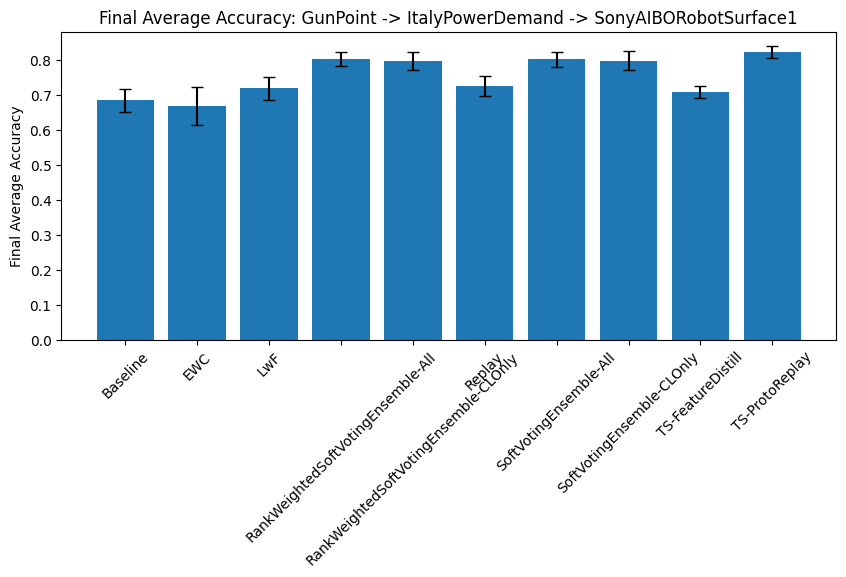

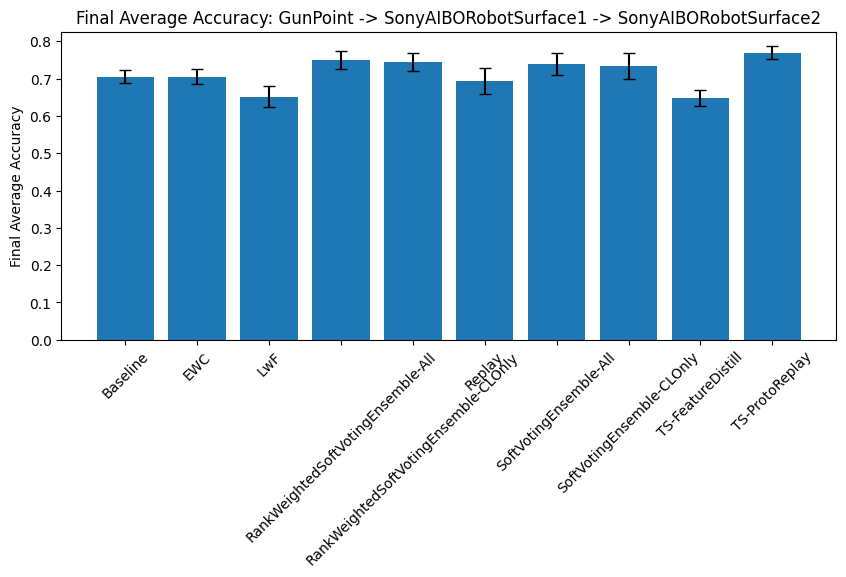

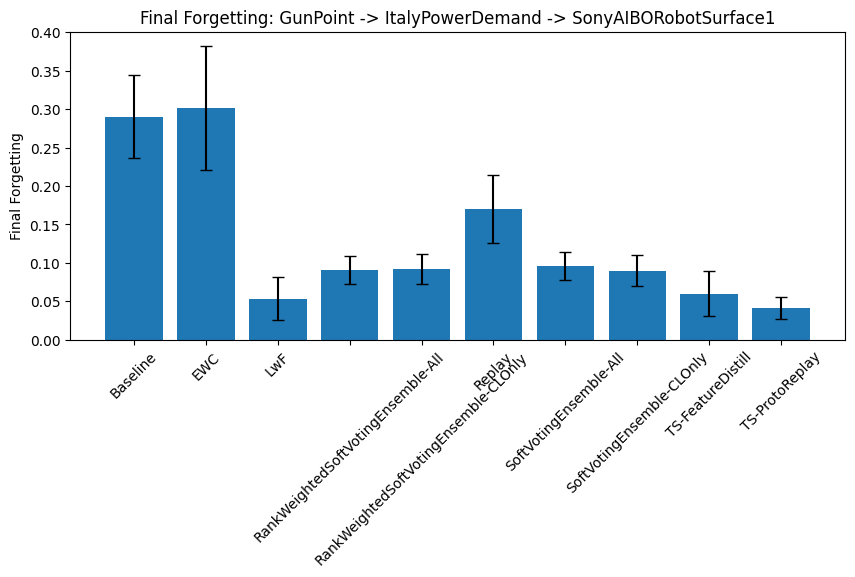

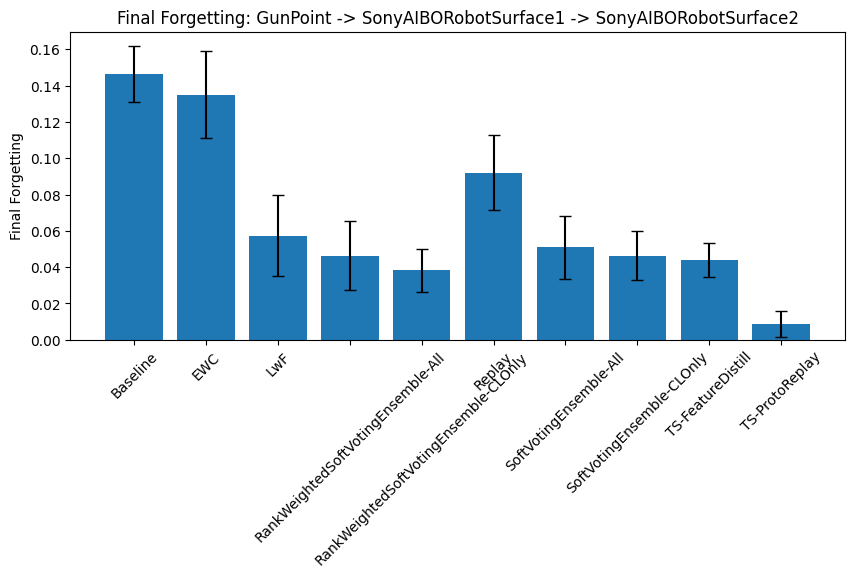

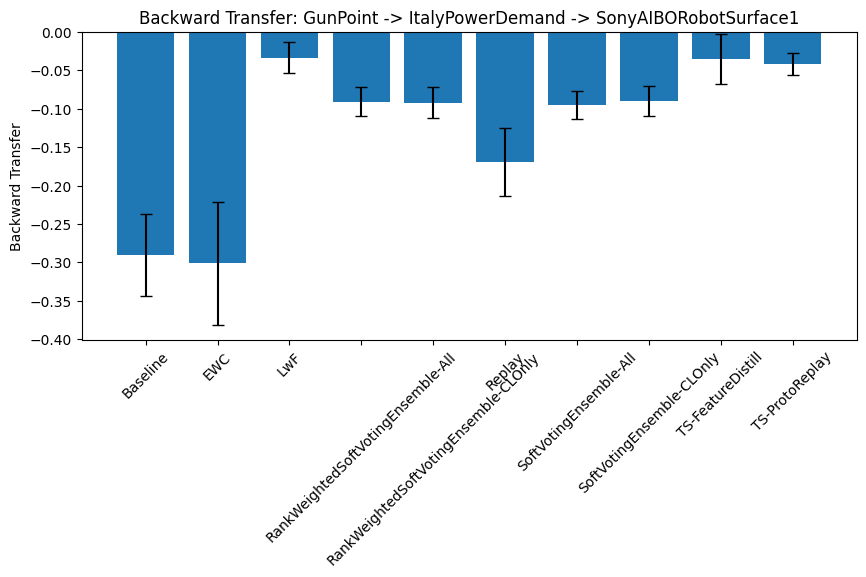

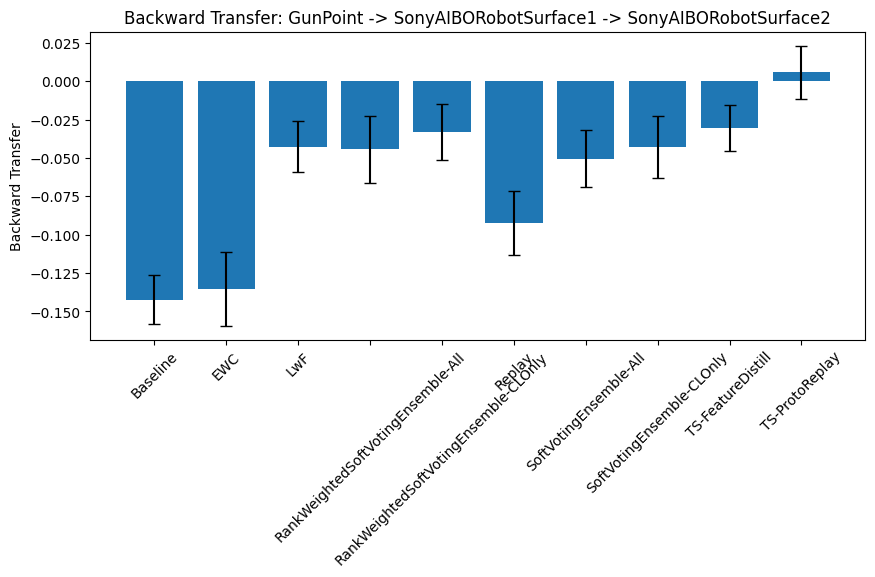

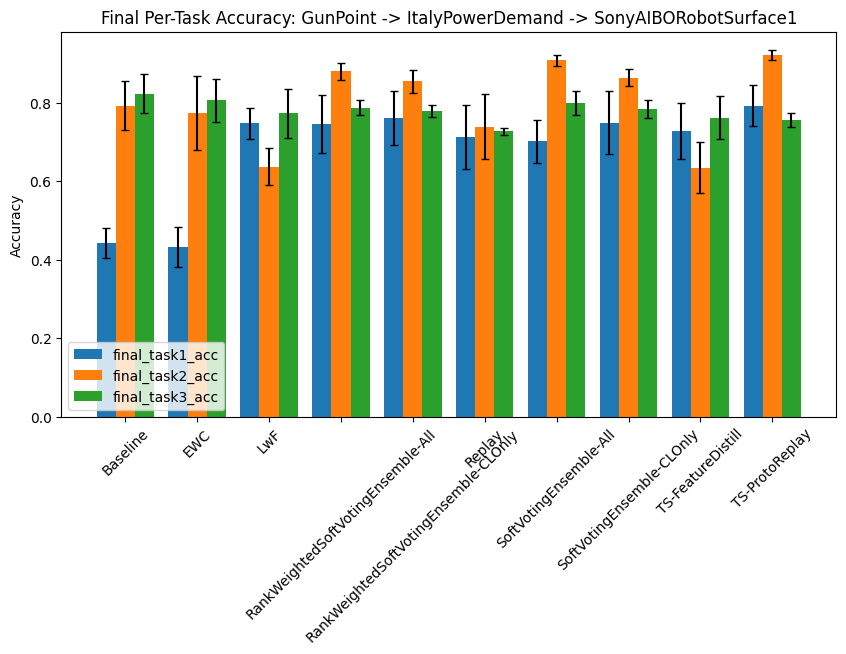

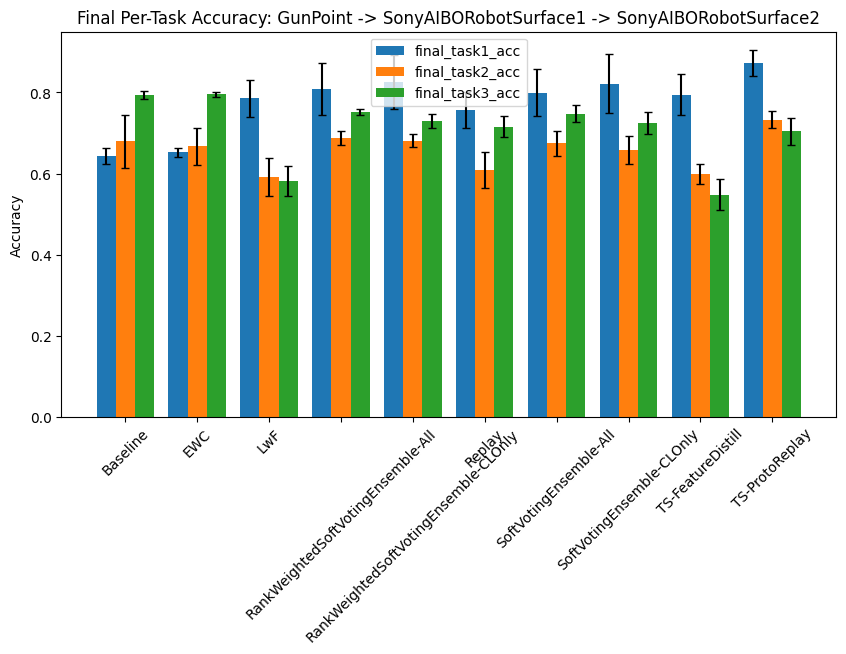

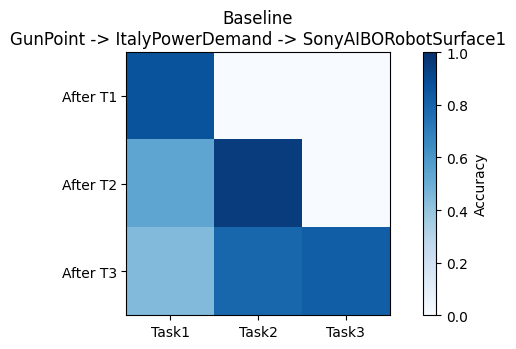

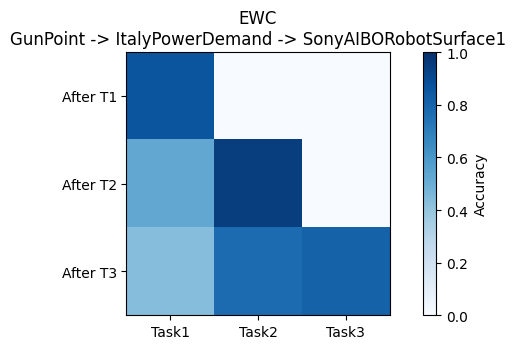

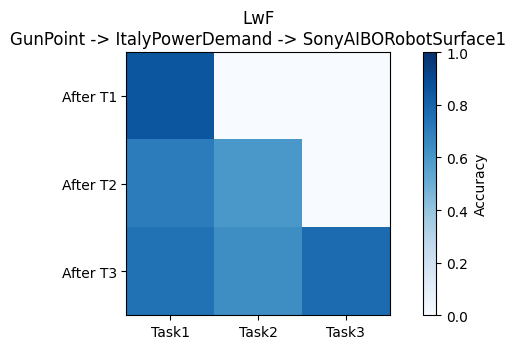

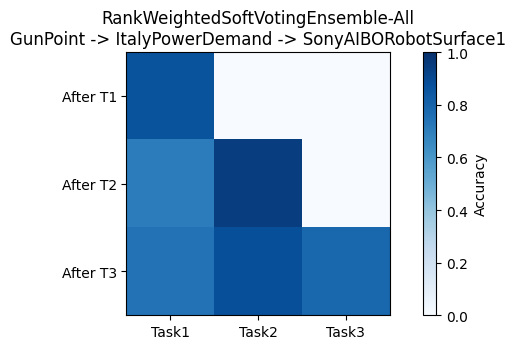

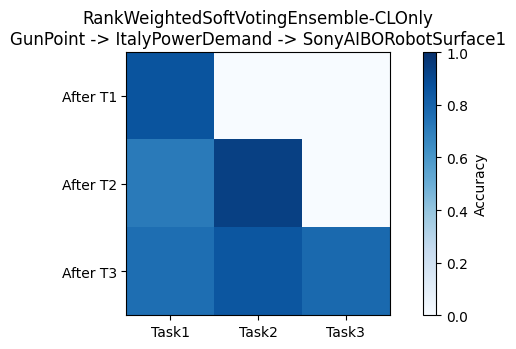

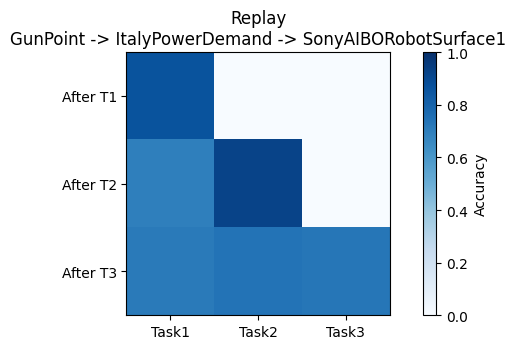

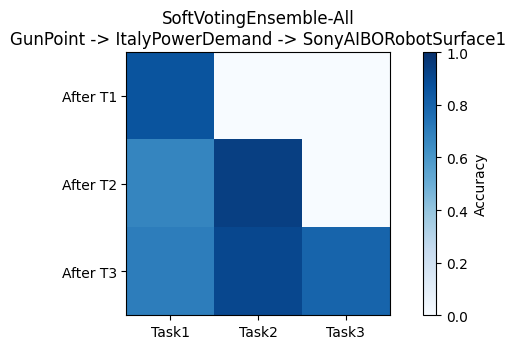

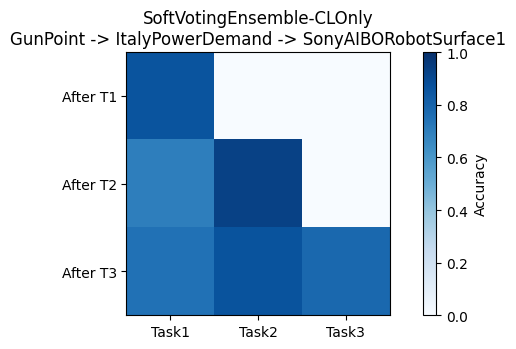

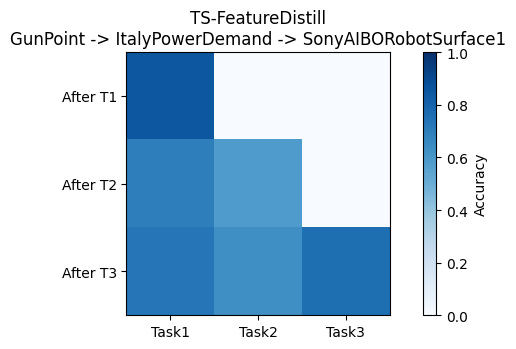

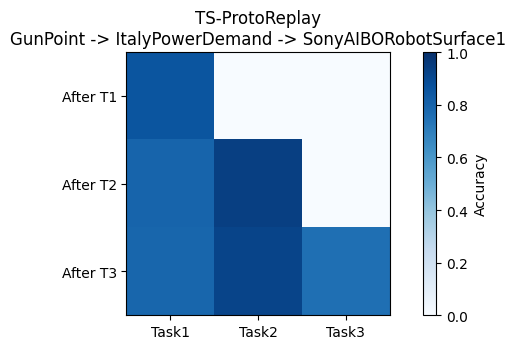

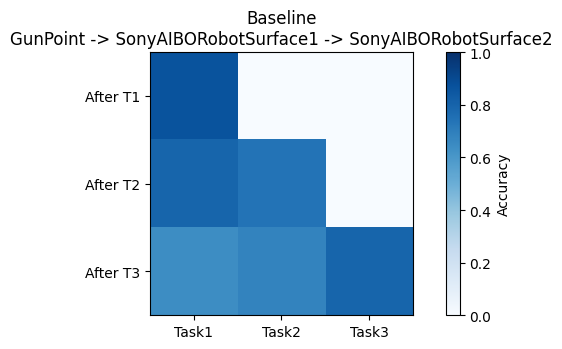

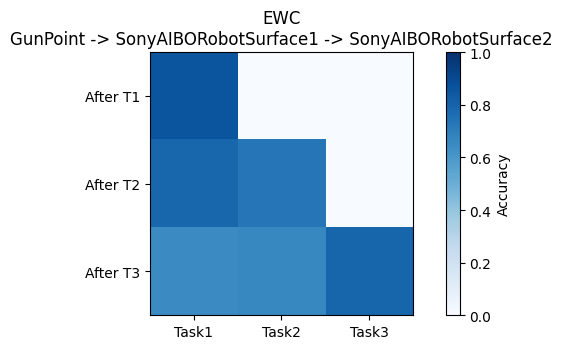

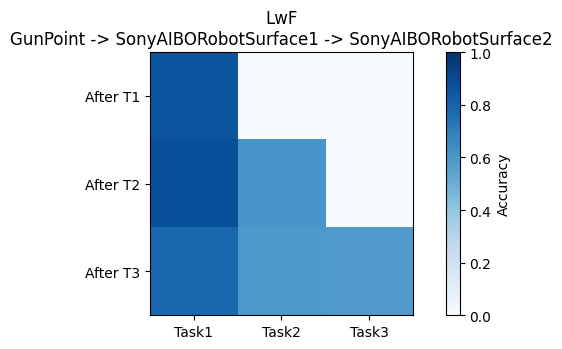

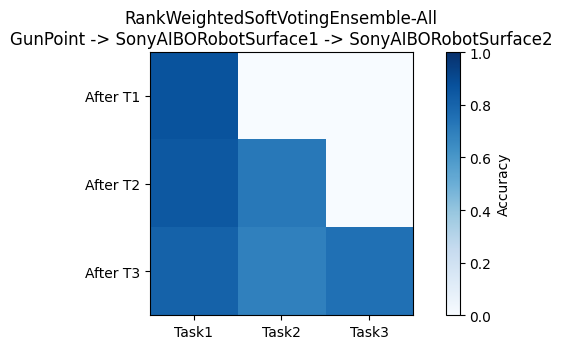

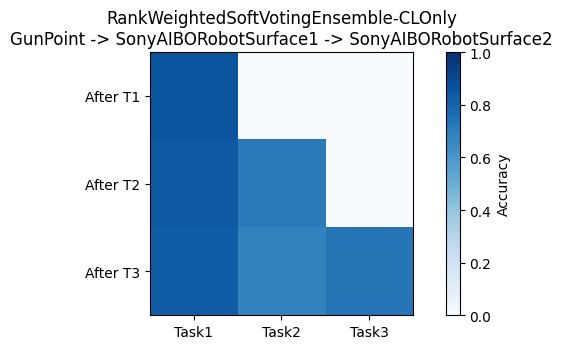

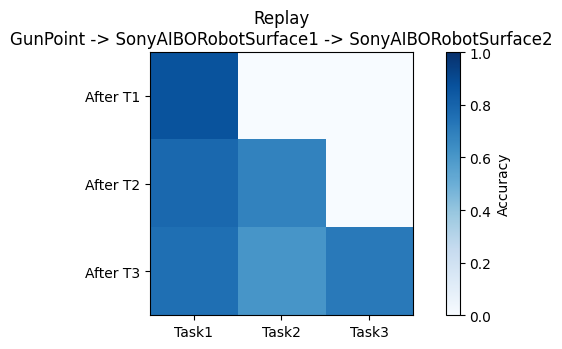

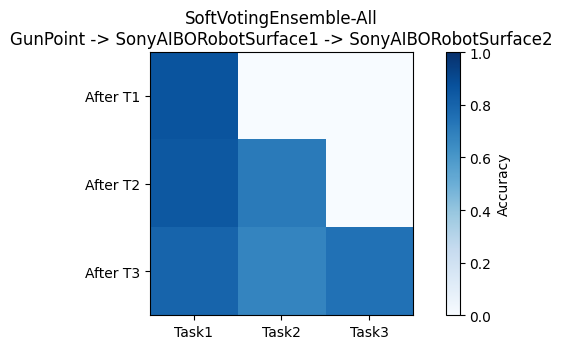

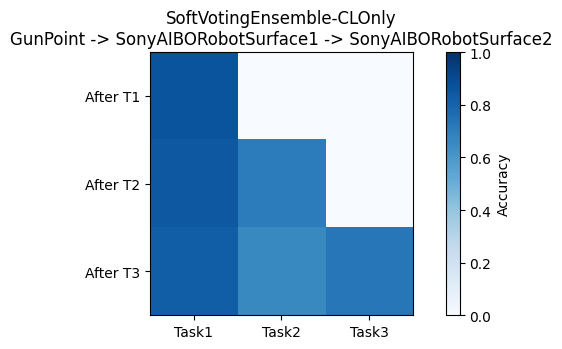

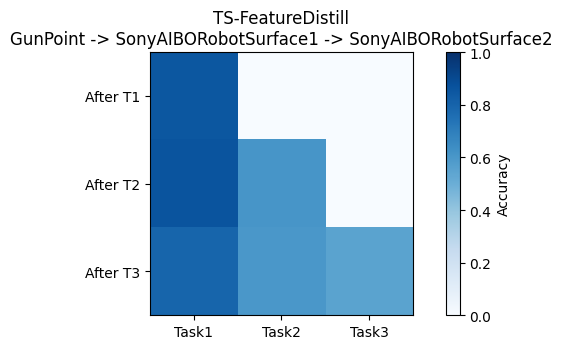

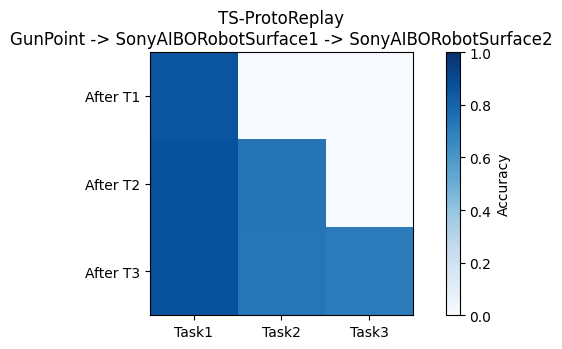

In [ ]:
# ============================================================
# 24) Plot results
# ============================================================
plot_sequence_results(agg_df, metric="final_avg_acc_mean")
plot_sequence_results(agg_df, metric="final_forgetting_mean")
plot_sequence_results(agg_df, metric="backward_transfer_mean")

plot_final_task_accuracies(agg_df)
plot_mean_accuracy_matrices(mat_agg)

In [ ]:
# ============================================================
# 25) Ranked views
# ============================================================
def rank_methods(agg_df, by="final_avg_acc_mean", ascending=False):
    return agg_df.sort_values(["sequence", by], ascending=[True, ascending]).copy()

print("\n=== Ranked by Final Average Accuracy ===")
display(rank_methods(agg_df, by="final_avg_acc_mean", ascending=False))

print("\n=== Ranked by Final Forgetting ===")
display(rank_methods(agg_df, by="final_forgetting_mean", ascending=True))

print("\n=== Ranked by Backward Transfer ===")
display(rank_methods(agg_df, by="backward_transfer_mean", ascending=False))


=== Ranked by Final Average Accuracy ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std,backward_transfer_mean,backward_transfer_std,final_task1_acc_mean,final_task1_acc_std,final_task2_acc_mean,final_task2_acc_std,final_task3_acc_mean,final_task3_acc_std
9,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-ProtoReplay,0.822813,0.016714,0.041427,0.014392,-0.041427,0.014392,0.792000,0.052366,0.920700,0.013175,0.755740,0.017703
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-All,0.804061,0.020110,0.090820,0.018742,-0.090820,0.018742,0.745333,0.074446,0.879495,0.022635,0.787354,0.018766
6,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-All,0.802606,0.020634,0.095757,0.018122,-0.095757,0.018122,0.701333,0.054853,0.907483,0.013560,0.799002,0.029447
7,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-CLOnly,0.798750,0.027818,0.089930,0.019889,-0.089930,0.019889,0.749333,0.080774,0.863557,0.021737,0.783361,0.023336
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-CLOnly,0.797532,0.026899,0.092163,0.019941,-0.092163,0.019941,0.760000,0.068475,0.854227,0.028837,0.778369,0.015671
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Replay,0.726095,0.029016,0.169753,0.044441,-0.169753,0.044441,0.712000,0.081021,0.739164,0.082440,0.727121,0.008646
2,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,LwF,0.719232,0.033339,0.053333,0.028186,-0.033508,0.020364,0.748000,0.039553,0.637318,0.046253,0.772379,0.062903
8,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-FeatureDistill,0.707933,0.017085,0.060000,0.029439,-0.035121,0.032326,0.728000,0.071709,0.634402,0.064233,0.761398,0.054600
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Baseline,0.685840,0.032902,0.290148,0.053619,-0.290148,0.053619,0.442667,0.038471,0.792225,0.061733,0.822629,0.049353
1,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,EWC,0.670260,0.054423,0.301186,0.080328,-0.301186,0.080328,0.432000,0.050200,0.772789,0.094635,0.805990,0.054333



=== Ranked by Final Forgetting ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std,backward_transfer_mean,backward_transfer_std,final_task1_acc_mean,final_task1_acc_std,final_task2_acc_mean,final_task2_acc_std,final_task3_acc_mean,final_task3_acc_std
9,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-ProtoReplay,0.822813,0.016714,0.041427,0.014392,-0.041427,0.014392,0.792000,0.052366,0.920700,0.013175,0.755740,0.017703
2,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,LwF,0.719232,0.033339,0.053333,0.028186,-0.033508,0.020364,0.748000,0.039553,0.637318,0.046253,0.772379,0.062903
8,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-FeatureDistill,0.707933,0.017085,0.060000,0.029439,-0.035121,0.032326,0.728000,0.071709,0.634402,0.064233,0.761398,0.054600
7,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-CLOnly,0.798750,0.027818,0.089930,0.019889,-0.089930,0.019889,0.749333,0.080774,0.863557,0.021737,0.783361,0.023336
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-All,0.804061,0.020110,0.090820,0.018742,-0.090820,0.018742,0.745333,0.074446,0.879495,0.022635,0.787354,0.018766
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-CLOnly,0.797532,0.026899,0.092163,0.019941,-0.092163,0.019941,0.760000,0.068475,0.854227,0.028837,0.778369,0.015671
6,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-All,0.802606,0.020634,0.095757,0.018122,-0.095757,0.018122,0.701333,0.054853,0.907483,0.013560,0.799002,0.029447
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Replay,0.726095,0.029016,0.169753,0.044441,-0.169753,0.044441,0.712000,0.081021,0.739164,0.082440,0.727121,0.008646
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Baseline,0.685840,0.032902,0.290148,0.053619,-0.290148,0.053619,0.442667,0.038471,0.792225,0.061733,0.822629,0.049353
1,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,EWC,0.670260,0.054423,0.301186,0.080328,-0.301186,0.080328,0.432000,0.050200,0.772789,0.094635,0.805990,0.054333



=== Ranked by Backward Transfer ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std,backward_transfer_mean,backward_transfer_std,final_task1_acc_mean,final_task1_acc_std,final_task2_acc_mean,final_task2_acc_std,final_task3_acc_mean,final_task3_acc_std
2,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,LwF,0.719232,0.033339,0.053333,0.028186,-0.033508,0.020364,0.748000,0.039553,0.637318,0.046253,0.772379,0.062903
8,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-FeatureDistill,0.707933,0.017085,0.060000,0.029439,-0.035121,0.032326,0.728000,0.071709,0.634402,0.064233,0.761398,0.054600
9,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-ProtoReplay,0.822813,0.016714,0.041427,0.014392,-0.041427,0.014392,0.792000,0.052366,0.920700,0.013175,0.755740,0.017703
7,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-CLOnly,0.798750,0.027818,0.089930,0.019889,-0.089930,0.019889,0.749333,0.080774,0.863557,0.021737,0.783361,0.023336
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-All,0.804061,0.020110,0.090820,0.018742,-0.090820,0.018742,0.745333,0.074446,0.879495,0.022635,0.787354,0.018766
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-CLOnly,0.797532,0.026899,0.092163,0.019941,-0.092163,0.019941,0.760000,0.068475,0.854227,0.028837,0.778369,0.015671
6,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-All,0.802606,0.020634,0.095757,0.018122,-0.095757,0.018122,0.701333,0.054853,0.907483,0.013560,0.799002,0.029447
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Replay,0.726095,0.029016,0.169753,0.044441,-0.169753,0.044441,0.712000,0.081021,0.739164,0.082440,0.727121,0.008646
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Baseline,0.685840,0.032902,0.290148,0.053619,-0.290148,0.053619,0.442667,0.038471,0.792225,0.061733,0.822629,0.049353
1,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,EWC,0.670260,0.054423,0.301186,0.080328,-0.301186,0.080328,0.432000,0.050200,0.772789,0.094635,0.805990,0.054333


In [ ]:
# ============================================================
# 27) Soft-voting ensemble helpers
# ============================================================
class SoftVotingEnsemble:
    def __init__(self, strategies, device, include_methods=None):
        self.device = device

        if include_methods is None:
            self.strategies = strategies
        else:
            self.strategies = {
                name: strat for name, strat in strategies.items()
                if name in include_methods
            }

        if len(self.strategies) == 0:
            raise ValueError("No strategies selected for ensemble.")

        self.include_methods = list(self.strategies.keys())

    def _collect_model_probabilities(self, X, batch_size=32):
        X_t = torch.tensor(X, dtype=torch.float32)
        loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=False)

        all_probs = {}

        for name, strategy in self.strategies.items():
            strategy.model.eval()
            probs_list = []

            with torch.no_grad():
                for batch in loader:
                    xb = batch[0].to(self.device)
                    logits = strategy.model(xb)
                    probs = torch.softmax(logits, dim=1)
                    probs_list.append(probs.cpu().numpy())

            all_probs[name] = np.vstack(probs_list)

        return all_probs

    def predict_proba(self, X, batch_size=32):
        all_probs = self._collect_model_probabilities(X, batch_size=batch_size)
        mean_probs = np.mean(list(all_probs.values()), axis=0)
        return mean_probs

    def predict(self, X, batch_size=32):
        probs = self.predict_proba(X, batch_size=batch_size)
        return np.argmax(probs, axis=1)

    def evaluate_task(self, task, batch_size=32):
        y_pred = self.predict(task.X_test, batch_size=batch_size)
        return accuracy_score(task.y_test, y_pred)


class WeightedSoftVotingEnsemble(SoftVotingEnsemble):
    def __init__(self, strategies, device, include_methods=None, weights=None):
        super().__init__(strategies, device, include_methods=include_methods)

        if weights is None:
            raise ValueError("weights must be provided for WeightedSoftVotingEnsemble")

        filtered_weights = {k: float(v) for k, v in weights.items() if k in self.strategies}

        if len(filtered_weights) == 0:
            raise ValueError("No matching weights found for selected ensemble strategies.")

        weight_sum = sum(filtered_weights.values())
        if weight_sum <= 0:
            n = len(filtered_weights)
            filtered_weights = {k: 1.0 / n for k in filtered_weights}
        else:
            filtered_weights = {k: v / weight_sum for k, v in filtered_weights.items()}

        self.weights = filtered_weights

    def predict_proba(self, X, batch_size=32):
        all_probs = self._collect_model_probabilities(X, batch_size=batch_size)

        weighted_probs = None
        for name, probs in all_probs.items():
            w = self.weights.get(name, 0.0)
            if weighted_probs is None:
                weighted_probs = w * probs
            else:
                weighted_probs += w * probs

        return weighted_probs

In [ ]:
# ============================================================
# 28) Rank-based weighting helpers
# ============================================================
def compute_rank_based_weights(score_dict):
    """
    Convert model scores to rank-based weights.

    Highest score gets highest rank weight.
    Then normalize to sum to 1.
    """
    items = list(score_dict.items())

    # sort descending by score
    items_sorted = sorted(items, key=lambda x: x[1], reverse=True)

    n = len(items_sorted)
    rank_weights = {}

    for rank_idx, (name, score) in enumerate(items_sorted):
        # best gets n, next n-1, ..., worst gets 1
        rank_weights[name] = float(n - rank_idx)

    total = sum(rank_weights.values())
    rank_weights = {k: v / total for k, v in rank_weights.items()}

    return rank_weights

In [ ]:
# ============================================================
# 29) Validation split helper
# ============================================================
def make_validation_split(X, y, val_ratio=0.2, seed=42):
    rng = np.random.RandomState(seed)
    indices = np.arange(len(X))
    rng.shuffle(indices)

    n_val = max(1, int(len(X) * val_ratio))
    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    if len(train_idx) == 0:
        train_idx = val_idx
        val_idx = indices[:1]

    X_train = X[train_idx]
    y_train = y[train_idx]
    X_val = X[val_idx]
    y_val = y[val_idx]

    return X_train, y_train, X_val, y_val

In [ ]:
# ============================================================
# 30) Task loader with validation split
# ============================================================
@dataclass
class TimeSeriesTask:
    name: str
    X_train: np.ndarray
    y_train: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    X_val: np.ndarray = None
    y_val: np.ndarray = None

class AeonTaskLoader:
    def __init__(self, target_length=150, only_first_channel=True, val_ratio=0.2, seed=42):
        self.target_length = target_length
        self.only_first_channel = only_first_channel
        self.val_ratio = val_ratio
        self.seed = seed

    def load_task(self, dataset_name):
        X_train, y_train = load_classification(dataset_name, split="train")
        X_test, y_test = load_classification(dataset_name, split="test")

        if X_train.ndim == 3:
            if self.only_first_channel:
                X_train = X_train[:, 0, :]
                X_test = X_test[:, 0, :]
            else:
                raise ValueError("Multivariate handling not implemented yet.")
        elif X_train.ndim != 2:
            raise ValueError(f"Unexpected shape for {dataset_name}: {X_train.shape}")

        X_train = np.array([resize_1d_series(x, self.target_length) for x in X_train], dtype=np.float32)
        X_test = np.array([resize_1d_series(x, self.target_length) for x in X_test], dtype=np.float32)

        le = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_test = le.transform(y_test)

        n_classes = len(np.unique(y_train))
        if n_classes != 2:
            raise ValueError(f"{dataset_name} is not binary. Found {n_classes} classes.")

        X_train_sub, y_train_sub, X_val, y_val = make_validation_split(
            X_train, y_train, val_ratio=self.val_ratio, seed=self.seed
        )

        scaler = StandardScaler()
        X_train_sub = scaler.fit_transform(X_train_sub).astype(np.float32)
        X_val = scaler.transform(X_val).astype(np.float32)
        X_test = scaler.transform(X_test).astype(np.float32)

        return TimeSeriesTask(
            name=dataset_name,
            X_train=X_train_sub,
            y_train=y_train_sub,
            X_test=X_test,
            y_test=y_test,
            X_val=X_val,
            y_val=y_val
        )

    def load_sequence(self, dataset_names):
        return [self.load_task(name) for name in dataset_names]

In [ ]:
# ============================================================
# 31) Sequence loading helper
# ============================================================
def load_task_sequence(task_names, target_length=150, val_ratio=0.2, seed=42):
    loader = AeonTaskLoader(
        target_length=target_length,
        only_first_channel=True,
        val_ratio=val_ratio,
        seed=seed
    )
    tasks = loader.load_sequence(task_names)
    return tasks

In [ ]:
# ============================================================
# 32) Experiment runner with rank-based weighted ensembles
# ============================================================
class ContinualLearningExperiment:
    def __init__(self, tasks, strategy_dict):
        self.tasks = tasks
        self.strategy_dict = strategy_dict
        self.results = {}
        self.trained_strategies = {}
        self.ensemble_weights_history = {}

    def _compute_validation_scores(self, upto_task_id, include_methods):
        """
        Compute mean validation accuracy over seen tasks for each selected method.
        """
        scores = {}

        for method_name in include_methods:
            strategy = self.trained_strategies[method_name]
            val_scores = []

            for eval_id in range(upto_task_id + 1):
                task = self.tasks[eval_id]
                if task.X_val is not None and task.y_val is not None:
                    val_task = TimeSeriesTask(
                        name=f"{task.name}_val",
                        X_train=None,
                        y_train=None,
                        X_test=task.X_val,
                        y_test=task.y_val
                    )
                    acc = strategy.evaluate_task(val_task)
                    val_scores.append(acc)

            if len(val_scores) == 0:
                scores[method_name] = 0.0
            else:
                scores[method_name] = float(np.mean(val_scores))

        return scores

    def _compute_rank_weights(self, upto_task_id, include_methods):
        scores = self._compute_validation_scores(upto_task_id, include_methods)
        weights = compute_rank_based_weights(scores)
        return scores, weights

    def run(self):
        n_tasks = len(self.tasks)

        for name in self.strategy_dict.keys():
            self.results[name] = np.zeros((n_tasks, n_tasks))

        self.trained_strategies = {name: strat for name, strat in self.strategy_dict.items()}

        ensemble_definitions = {
            "SoftVotingEnsemble-All": list(self.strategy_dict.keys()),
            "SoftVotingEnsemble-CLOnly": [
                m for m in ["EWC", "LwF", "Replay", "TS-FeatureDistill", "TS-ProtoReplay"]
                if m in self.strategy_dict
            ],
        }

        weighted_ensemble_definitions = {
            "RankWeightedSoftVotingEnsemble-All": list(self.strategy_dict.keys()),
            "RankWeightedSoftVotingEnsemble-CLOnly": [
                m for m in ["EWC", "LwF", "Replay", "TS-FeatureDistill", "TS-ProtoReplay"]
                if m in self.strategy_dict
            ],
        }

        for ensemble_name in ensemble_definitions.keys():
            self.results[ensemble_name] = np.zeros((n_tasks, n_tasks))

        for ensemble_name in weighted_ensemble_definitions.keys():
            self.results[ensemble_name] = np.zeros((n_tasks, n_tasks))

        for task_id, task in enumerate(self.tasks):
            print(f"\n==============================")
            print(f"Training phase: Task {task_id+1} / {n_tasks} -> {task.name}")
            print(f"==============================")

            # train individual strategies
            for name, strategy in self.strategy_dict.items():
                print(f"\nRunning strategy: {name}")
                strategy.fit_task(task, task_id=task_id)

                for eval_id in range(task_id + 1):
                    acc = strategy.evaluate_task(self.tasks[eval_id])
                    self.results[name][task_id, eval_id] = acc
                    print(f"  Eval on task {eval_id+1} ({self.tasks[eval_id].name}): {acc:.4f}")

            # unweighted ensembles
            for ensemble_name, include_methods in ensemble_definitions.items():
                ensemble = SoftVotingEnsemble(
                    strategies=self.trained_strategies,
                    device=list(self.trained_strategies.values())[0].device,
                    include_methods=include_methods
                )

                print(f"\nRunning ensemble: {ensemble_name}")
                print(f"  Included methods: {ensemble.include_methods}")

                for eval_id in range(task_id + 1):
                    acc = ensemble.evaluate_task(self.tasks[eval_id])
                    self.results[ensemble_name][task_id, eval_id] = acc
                    print(f"  Eval on task {eval_id+1} ({self.tasks[eval_id].name}): {acc:.4f}")

            # rank-weighted ensembles
            for ensemble_name, include_methods in weighted_ensemble_definitions.items():
                scores, weights = self._compute_rank_weights(task_id, include_methods)
                self.ensemble_weights_history[(ensemble_name, task_id)] = weights

                ensemble = WeightedSoftVotingEnsemble(
                    strategies=self.trained_strategies,
                    device=list(self.trained_strategies.values())[0].device,
                    include_methods=include_methods,
                    weights=weights
                )

                print(f"\nRunning ensemble: {ensemble_name}")
                print(f"  Included methods: {ensemble.include_methods}")
                print(f"  Validation scores: {scores}")
                print(f"  Rank-based weights: {weights}")

                for eval_id in range(task_id + 1):
                    acc = ensemble.evaluate_task(self.tasks[eval_id])
                    self.results[ensemble_name][task_id, eval_id] = acc
                    print(f"  Eval on task {eval_id+1} ({self.tasks[eval_id].name}): {acc:.4f}")

        return self.results

    def summary(self):
        rows = []
        for name, acc_matrix in self.results.items():
            row = {
                "method": name,
                "final_avg_acc": final_average_accuracy(acc_matrix),
                "final_forgetting": final_forgetting(acc_matrix),
                "backward_transfer": backward_transfer(acc_matrix),
            }

            final_task_accs = per_task_final_accuracy(acc_matrix)
            for i, acc in enumerate(final_task_accs):
                row[f"final_task{i+1}_acc"] = acc

            rows.append(row)

        return pd.DataFrame(rows)

In [ ]:
# ============================================================
# 33) Single run: one sequence, one seed
# ============================================================
def run_one_sequence_one_seed(task_names, seed, device, target_length=150, verbose=True):
    set_seed(seed)

    tasks = load_task_sequence(
        task_names,
        target_length=target_length,
        val_ratio=0.2,
        seed=seed
    )
    input_dim = tasks[0].X_train.shape[1]

    strategies = make_strategies(input_dim, device)

    experiment = ContinualLearningExperiment(tasks, strategies)
    experiment.run()
    summary_df = experiment.summary()

    sequence_name = " -> ".join(task_names)
    summary_df["sequence"] = sequence_name
    summary_df["seed"] = seed

    matrices = {}
    for method, acc_matrix in experiment.results.items():
        matrices[method] = acc_matrix.copy()

    if verbose:
        print(f"\nFinished sequence: {sequence_name}, seed: {seed}")
        display(summary_df)

    return {
        "sequence": sequence_name,
        "seed": seed,
        "summary": summary_df,
        "matrices": matrices,
        "task_names": task_names,
        "ensemble_weights_history": experiment.ensemble_weights_history,
    }

In [ ]:
# ============================================================
# 34) Full benchmark runner
# ============================================================
def run_benchmark(sequences, seeds, device, target_length=150, verbose=False):
    all_runs = []

    for seq in sequences:
        for seed in seeds:
            print("\n############################################")
            print(f"Running sequence {seq} with seed {seed}")
            print("############################################")

            run_data = run_one_sequence_one_seed(
                task_names=seq,
                seed=seed,
                device=device,
                target_length=target_length,
                verbose=verbose
            )
            all_runs.append(run_data)

    return all_runs

In [ ]:
# ============================================================
# 35) Ensemble weight aggregation
# ============================================================
def aggregate_ensemble_weights(all_runs):
    rows = []

    for run in all_runs:
        sequence = run["sequence"]
        seed = run["seed"]
        weight_hist = run.get("ensemble_weights_history", {})

        for (ensemble_name, task_id), weights in weight_hist.items():
            row = {
                "sequence": sequence,
                "seed": seed,
                "ensemble": ensemble_name,
                "task_phase": task_id + 1,
            }
            for method_name, value in weights.items():
                row[method_name] = value
            rows.append(row)

    if len(rows) == 0:
        return pd.DataFrame(), pd.DataFrame()

    weights_df = pd.DataFrame(rows)

    id_cols = ["sequence", "ensemble", "task_phase"]
    method_cols = [c for c in weights_df.columns if c not in ["sequence", "seed", "ensemble", "task_phase"]]

    agg_dict = {}
    for col in method_cols:
        agg_dict[f"{col}_mean"] = (col, "mean")
        agg_dict[f"{col}_std"] = (col, "std")

    weights_agg = (
        weights_df.groupby(id_cols)
        .agg(**agg_dict)
        .reset_index()
    )

    return weights_df, weights_agg

In [ ]:
# ============================================================
# 36) Ensemble-only comparison tables
# ============================================================
def build_ensemble_comparison_table(agg_df):
    ensemble_methods = [
        "SoftVotingEnsemble-All",
        "SoftVotingEnsemble-CLOnly",
        "RankWeightedSoftVotingEnsemble-All",
        "RankWeightedSoftVotingEnsemble-CLOnly",
    ]

    ens_df = agg_df[agg_df["method"].isin(ensemble_methods)].copy()

    cols_to_keep = [
        "sequence",
        "method",
        "final_avg_acc_mean",
        "final_avg_acc_std",
        "final_forgetting_mean",
        "final_forgetting_std",
        "backward_transfer_mean",
        "backward_transfer_std",
    ]

    final_task_cols = [c for c in ens_df.columns if c.startswith("final_task") and (c.endswith("_mean") or c.endswith("_std"))]
    cols_to_keep.extend(final_task_cols)
    cols_to_keep = [c for c in cols_to_keep if c in ens_df.columns]

    ens_df = ens_df[cols_to_keep].copy()
    return ens_df

def build_ensemble_pivot_table(agg_df, metric="final_avg_acc_mean"):
    ensemble_methods = [
        "SoftVotingEnsemble-All",
        "SoftVotingEnsemble-CLOnly",
        "RankWeightedSoftVotingEnsemble-All",
        "RankWeightedSoftVotingEnsemble-CLOnly",
    ]

    ens_df = agg_df[agg_df["method"].isin(ensemble_methods)].copy()
    pivot_df = ens_df.pivot(index="sequence", columns="method", values=metric)
    return pivot_df

def highlight_best_ensemble_per_sequence(agg_df, metric="final_avg_acc_mean", maximize=True):
    ensemble_methods = [
        "SoftVotingEnsemble-All",
        "SoftVotingEnsemble-CLOnly",
        "RankWeightedSoftVotingEnsemble-All",
        "RankWeightedSoftVotingEnsemble-CLOnly",
    ]

    ens_df = agg_df[agg_df["method"].isin(ensemble_methods)].copy()

    rows = []
    for sequence in ens_df["sequence"].unique():
        sub = ens_df[ens_df["sequence"] == sequence].copy()

        best_idx = sub[metric].idxmax() if maximize else sub[metric].idxmin()
        best_row = sub.loc[best_idx]

        rows.append({
            "sequence": sequence,
            "best_method": best_row["method"],
            metric: best_row[metric]
        })

    return pd.DataFrame(rows)

def build_compact_ensemble_table(agg_df):
    ensemble_methods = [
        "SoftVotingEnsemble-All",
        "SoftVotingEnsemble-CLOnly",
        "RankWeightedSoftVotingEnsemble-All",
        "RankWeightedSoftVotingEnsemble-CLOnly",
    ]

    ens_df = agg_df[agg_df["method"].isin(ensemble_methods)].copy()

    ens_df["final_avg_acc"] = ens_df.apply(
        lambda r: f"{r['final_avg_acc_mean']:.4f} ± {0.0 if pd.isna(r['final_avg_acc_std']) else r['final_avg_acc_std']:.4f}",
        axis=1
    )
    ens_df["final_forgetting"] = ens_df.apply(
        lambda r: f"{r['final_forgetting_mean']:.4f} ± {0.0 if pd.isna(r['final_forgetting_std']) else r['final_forgetting_std']:.4f}",
        axis=1
    )
    ens_df["backward_transfer"] = ens_df.apply(
        lambda r: f"{r['backward_transfer_mean']:.4f} ± {0.0 if pd.isna(r['backward_transfer_std']) else r['backward_transfer_std']:.4f}",
        axis=1
    )

    compact_cols = ["sequence", "method", "final_avg_acc", "final_forgetting", "backward_transfer"]

    final_task_mean_cols = sorted([c for c in ens_df.columns if c.startswith("final_task") and c.endswith("_mean")])
    for mean_col in final_task_mean_cols:
        std_col = mean_col.replace("_mean", "_std")
        new_col = mean_col.replace("_mean", "")
        ens_df[new_col] = ens_df.apply(
            lambda r: f"{r[mean_col]:.4f} ± {0.0 if pd.isna(r.get(std_col, np.nan)) else r[std_col]:.4f}",
            axis=1
        )
        compact_cols.append(new_col)

    return ens_df[compact_cols].copy()

In [ ]:
# ============================================================
# 37) Aggregate and show rank-weighted ensemble results
# ============================================================
full_df, agg_df = aggregate_results(all_runs)
mat_df, mat_agg = aggregate_accuracy_matrices(all_runs)
weights_df, weights_agg = aggregate_ensemble_weights(all_runs)

print("\n=== Ensemble-only detailed comparison ===")
ensemble_compare_df = build_ensemble_comparison_table(agg_df)
display(ensemble_compare_df)

print("\n=== Ensemble-only pivot: Final Average Accuracy ===")
ensemble_pivot_avg = build_ensemble_pivot_table(agg_df, metric="final_avg_acc_mean")
display(ensemble_pivot_avg)

print("\n=== Ensemble-only pivot: Final Forgetting ===")
ensemble_pivot_forgetting = build_ensemble_pivot_table(agg_df, metric="final_forgetting_mean")
display(ensemble_pivot_forgetting)

print("\n=== Ensemble-only pivot: Backward Transfer ===")
ensemble_pivot_bwt = build_ensemble_pivot_table(agg_df, metric="backward_transfer_mean")
display(ensemble_pivot_bwt)

print("\n=== Best ensemble per sequence by Final Average Accuracy ===")
best_ensemble_avg = highlight_best_ensemble_per_sequence(
    agg_df,
    metric="final_avg_acc_mean",
    maximize=True
)
display(best_ensemble_avg)

print("\n=== Best ensemble per sequence by Final Forgetting ===")
best_ensemble_forgetting = highlight_best_ensemble_per_sequence(
    agg_df,
    metric="final_forgetting_mean",
    maximize=False
)
display(best_ensemble_forgetting)

print("\n=== Best ensemble per sequence by Backward Transfer ===")
best_ensemble_bwt = highlight_best_ensemble_per_sequence(
    agg_df,
    metric="backward_transfer_mean",
    maximize=True
)
display(best_ensemble_bwt)

print("\n=== Compact ensemble-only comparison table ===")
compact_ensemble_df = build_compact_ensemble_table(agg_df)
display(compact_ensemble_df)


=== Ensemble-only detailed comparison ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std,backward_transfer_mean,backward_transfer_std,final_task1_acc_mean,final_task1_acc_std,final_task2_acc_mean,final_task2_acc_std,final_task3_acc_mean,final_task3_acc_std
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-All,0.804061,0.020110,0.090820,0.018742,-0.090820,0.018742,0.745333,0.074446,0.879495,0.022635,0.787354,0.018766
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-CLOnly,0.797532,0.026899,0.092163,0.019941,-0.092163,0.019941,0.760000,0.068475,0.854227,0.028837,0.778369,0.015671
6,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-All,0.802606,0.020634,0.095757,0.018122,-0.095757,0.018122,0.701333,0.054853,0.907483,0.013560,0.799002,0.029447
7,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-CLOnly,0.798750,0.027818,0.089930,0.019889,-0.089930,0.019889,0.749333,0.080774,0.863557,0.021737,0.783361,0.023336
13,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,RankWeightedSoftVotingEnsemble-All,0.749166,0.024049,0.046305,0.019040,-0.044306,0.021864,0.808000,0.063491,0.688186,0.016664,0.751312,0.007991
14,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,RankWeightedSoftVotingEnsemble-CLOnly,0.745158,0.023845,0.038305,0.011837,-0.033141,0.018121,0.825333,0.066900,0.680865,0.015538,0.729276,0.017808
16,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,SoftVotingEnsemble-All,0.740318,0.029337,0.050967,0.017381,-0.050301,0.018757,0.798667,0.058004,0.674542,0.030807,0.747744,0.020757
17,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,SoftVotingEnsemble-CLOnly,0.735023,0.035168,0.046294,0.013625,-0.042961,0.020127,0.821333,0.072326,0.658236,0.034854,0.725498,0.026820



=== Ensemble-only pivot: Final Average Accuracy ===


method,RankWeightedSoftVotingEnsemble-All,RankWeightedSoftVotingEnsemble-CLOnly,SoftVotingEnsemble-All,SoftVotingEnsemble-CLOnly
sequence,,,,
GunPoint -> ItalyPowerDemand -> SonyAIBORobotSurface1,0.804061,0.797532,0.802606,0.798750
GunPoint -> SonyAIBORobotSurface1 -> SonyAIBORobotSurface2,0.749166,0.745158,0.740318,0.735023



=== Ensemble-only pivot: Final Forgetting ===


...

,sequence,best_method,final_forgetting_mean
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-CLOnly,0.089930
1,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,RankWeightedSoftVotingEnsemble-CLOnly,0.038305



=== Best ensemble per sequence by Backward Transfer ===


,sequence,best_method,backward_transfer_mean
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-CLOnly,-0.089930
1,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,RankWeightedSoftVotingEnsemble-CLOnly,-0.033141



=== Compact ensemble-only comparison table ===


,sequence,method,final_avg_acc,final_forgetting,backward_transfer,final_task1_acc,final_task2_acc,final_task3_acc
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-All,0.8041 ± 0.0201,0.0908 ± 0.0187,-0.0908 ± 0.0187,0.7453 ± 0.0744,0.8795 ± 0.0226,0.7874 ± 0.0188
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,RankWeightedSoftVotingEnsemble-CLOnly,0.7975 ± 0.0269,0.0922 ± 0.0199,-0.0922 ± 0.0199,0.7600 ± 0.0685,0.8542 ± 0.0288,0.7784 ± 0.0157
6,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-All,0.8026 ± 0.0206,0.0958 ± 0.0181,-0.0958 ± 0.0181,0.7013 ± 0.0549,0.9075 ± 0.0136,0.7990 ± 0.0294
7,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-CLOnly,0.7988 ± 0.0278,0.0899 ± 0.0199,-0.0899 ± 0.0199,0.7493 ± 0.0808,0.8636 ± 0.0217,0.7834 ± 0.0233
13,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,RankWeightedSoftVotingEnsemble-All,0.7492 ± 0.0240,0.0463 ± 0.0190,-0.0443 ± 0.0219,0.8080 ± 0.0635,0.6882 ± 0.0167,0.7513 ± 0.0080
14,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,RankWeightedSoftVotingEnsemble-CLOnly,0.7452 ± 0.0238,0.0383 ± 0.0118,-0.0331 ± 0.0181,0.8253 ± 0.0669,0.6809 ± 0.0155,0.7293 ± 0.0178
16,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,SoftVotingEnsemble-All,0.7403 ± 0.0293,0.0510 ± 0.0174,-0.0503 ± 0.0188,0.7987 ± 0.0580,0.6745 ± 0.0308,0.7477 ± 0.0208
17,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,SoftVotingEnsemble-CLOnly,0.7350 ± 0.0352,0.0463 ± 0.0136,-0.0430 ± 0.0201,0.8213 ± 0.0723,0.6582 ± 0.0349,0.7255 ± 0.0268


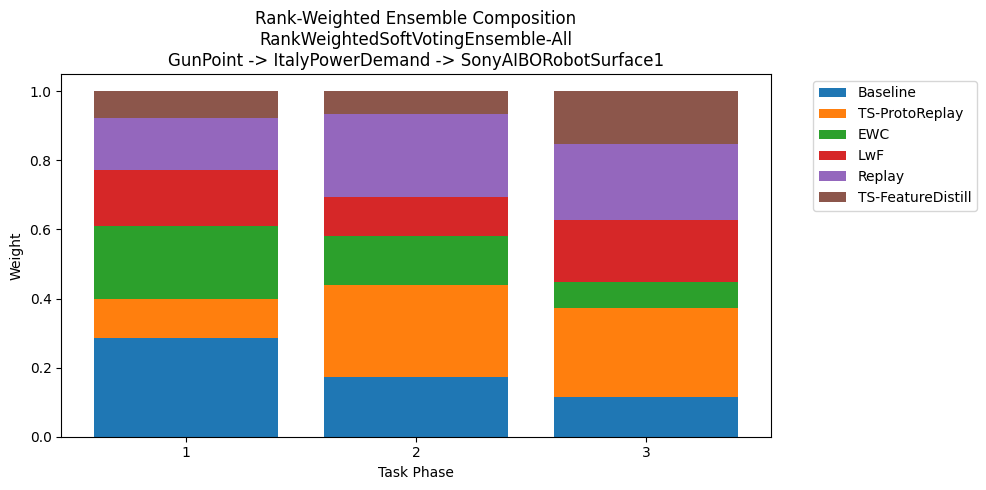

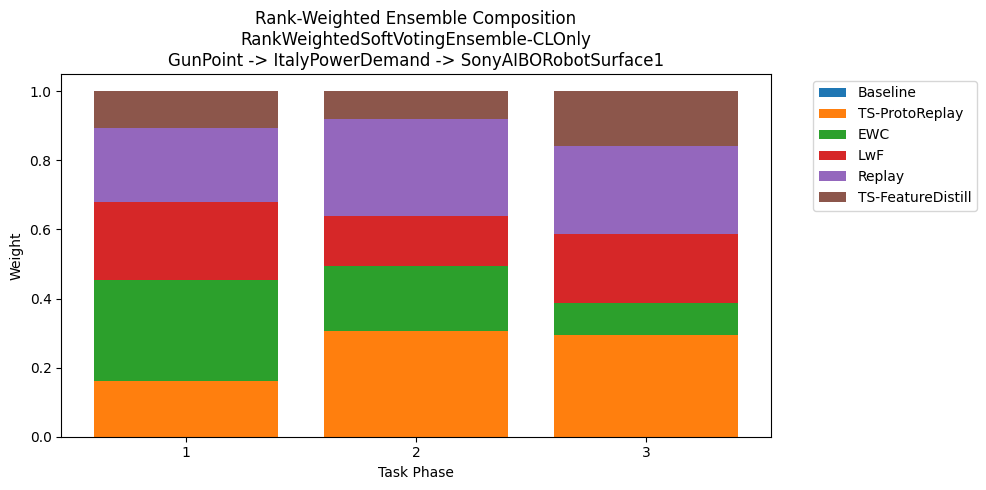

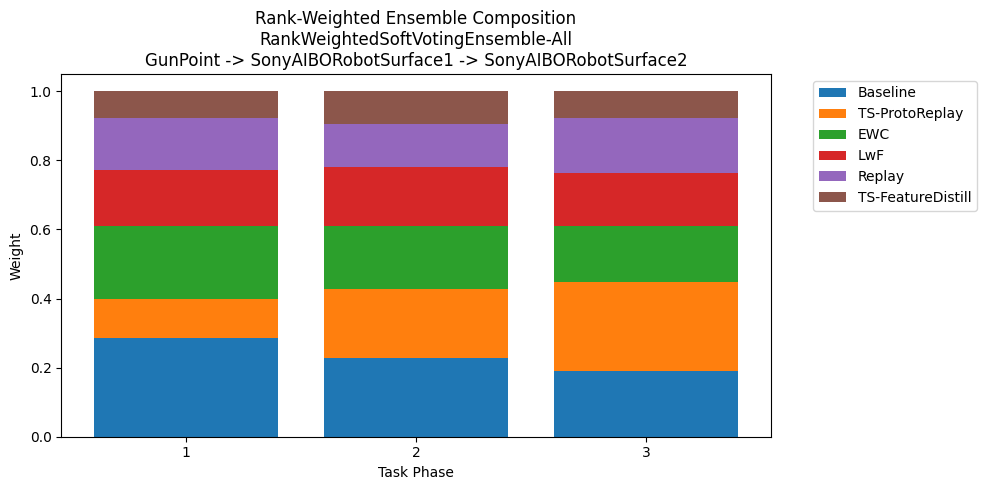

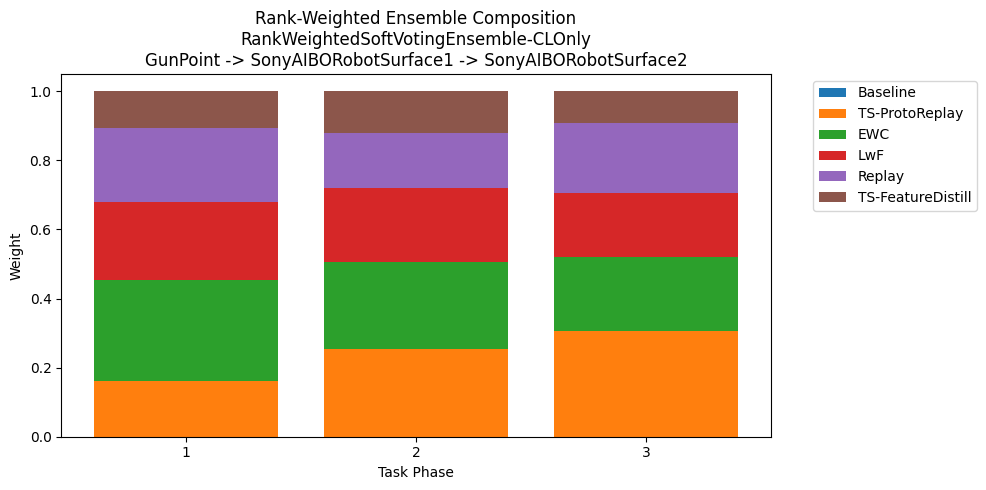

In [ ]:
# ============================================================
# 38) Plot rank-based ensemble weights
# ============================================================
def plot_ensemble_weights(weights_agg):
    if len(weights_agg) == 0:
        print("No ensemble weights found.")
        return

    sequences = weights_agg["sequence"].unique()
    ensembles = weights_agg["ensemble"].unique()

    for seq in sequences:
        for ens in ensembles:
            sub = weights_agg[(weights_agg["sequence"] == seq) & (weights_agg["ensemble"] == ens)].copy()
            if len(sub) == 0:
                continue

            mean_cols = [c for c in sub.columns if c.endswith("_mean")]
            method_names = [c.replace("_mean", "") for c in mean_cols]

            plt.figure(figsize=(10, 5))
            bottom = np.zeros(len(sub))
            phases = sub["task_phase"].values

            for col, method in zip(mean_cols, method_names):
                values = sub[col].fillna(0).values
                plt.bar(phases, values, bottom=bottom, label=method)
                bottom += values

            plt.xlabel("Task Phase")
            plt.ylabel("Weight")
            plt.title(f"Rank-Weighted Ensemble Composition\n{ens}\n{seq}")
            plt.xticks(phases)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()

plot_ensemble_weights(weights_agg)